# Patent Analysis - Modularized Notebook

This notebook performs comprehensive patent analysis using modularized functions from `utils/patent.py`. 
It covers:
- Data loading and preparation
- Abstract cleaning
- Country assignment from assignees
- Topic parsing and hierarchical classification
- LLM-based classification (using pre-computed results to skip re-running)
- Summary statistics and visualizations
- Data export

**Note**: LLM classification results are loaded from saved checkpoints, so no actual LLM calls are made in this notebook.

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import modularized functions from patent.py
from utils import patent

# Setup environment
os.chdir(Path.cwd().parent)

# Define color scheme for visualizations
colors_scheme = ["#B80C09", "#D4AF37", "#6E8B3D", "#345995"]

# Set plot style
plt.rcParams['figure.dpi'] = 300

## 1. Load Patent Data

Load the main patent dataset and reference data (UK Biobank papers).

In [2]:
# Load patent data
df_patent = pd.read_csv('data/patent/patents_detailed.csv')
df_all_ukbb = pd.read_excel("data/df_dimensions.xlsx")

print(f"✓ Patents loaded: {len(df_patent)} patents")
print(f"✓ UK Biobank papers loaded: {len(df_all_ukbb)} papers")
print(f"\nPatent data shape: {df_patent.shape}")
print(f"Missing abstracts: {df_patent['abstract'].isnull().sum()}")
print(f"\nSample columns: {df_patent.columns.tolist()[:10]}")

✓ Patents loaded: 513 patents
✓ UK Biobank papers loaded: 10846 papers

Patent data shape: (513, 56)
Missing abstracts: 16

Sample columns: ['abstract', 'additional_filters', 'application_number', 'assignee_cities', 'assignee_countries', 'assignee_names', 'assignees', 'category_for', 'category_for_2020', 'category_rcdc']


## 2. Data Preparation and Cleaning

Clean patent abstracts and prepare data for analysis.

In [3]:
# Clean abstracts using modularized function
df_patent["abstract_clean"] = df_patent["abstract"].apply(patent.clean_patent_abstract)

# Prepare publication dates
df_patent['publication_date'] = pd.to_datetime(df_patent['publication_date'], errors='coerce')
df_patent['publication_year'] = df_patent['publication_date'].dt.year
df_patent['year'] = df_patent['publication_year']

print(f"✓ Abstracts cleaned: {df_patent['abstract_clean'].notna().sum()} non-null abstracts")
print(f"✓ Publication dates processed: {df_patent['publication_year'].notna().sum()} valid dates")
print(f"\nYear range: {df_patent['publication_year'].min():.0f} - {df_patent['publication_year'].max():.0f}")

✓ Abstracts cleaned: 497 non-null abstracts
✓ Publication dates processed: 513 valid dates

Year range: 2018 - 2025


## 3. Country Assignment from Assignees

Assign country information to patents using patent assignee metadata.

In [4]:
# Assign country information using modularized function
# Use aggressive mode to include rule-based inference
df_with_iso = patent.assign_assignee_countries_with_iso(
    df_patent,
    assignee_col='assignees',
    assignee_names_col='assignee_names',
    use_low_confidence=True,
    primary_pick='most_common'
)

print(f"✓ Country assignment completed")
print(f"✓ Patents with country info: {df_with_iso['assignee_countries'].notna().sum()}")
print(f"\nTop 10 countries:")
all_countries = []
for countries in df_with_iso['assignee_countries']:
    if isinstance(countries, list):
        all_countries.extend(countries)

country_counts = Counter(all_countries)
for country, count in country_counts.most_common(10):
    print(f"  {country}: {count}")


✓ Country assignment completed
✓ Patents with country info: 513

Top 10 countries:
  US: 268
  GB: 65
  FR: 53
  KR: 37
  None: 34
  CN: 31
  DE: 27
  JP: 18
  BE: 13
  CH: 12


## 4. Topic Parsing and Hierarchical Classification

Parse patent topics and organize them hierarchically by FOR (Field of Research) codes.

In [5]:
# Parse patent topics using modularized function
df_with_iso = patent.parse_patent_topics(df_with_iso, category_col='category_for')

print(f"✓ Topics parsed for patents")
print(f"✓ Patents with topic data: {df_with_iso['topics_list'].notna().sum()}")

# Calculate topic statistics
df_with_iso['n_topics'] = df_with_iso['topics_list'].apply(len)
avg_topics = df_with_iso['n_topics'].mean()
median_topics = df_with_iso['n_topics'].median()

print(f"\nTopic statistics:")
print(f"  Average topics per patent: {avg_topics:.2f}")
print(f"  Median topics per patent: {median_topics:.0f}")
print(f"  Max topics in a patent: {df_with_iso['n_topics'].max()}")


✓ Topics parsed for patents
✓ Patents with topic data: 513

Topic statistics:
  Average topics per patent: 3.23
  Median topics per patent: 3
  Max topics in a patent: 9


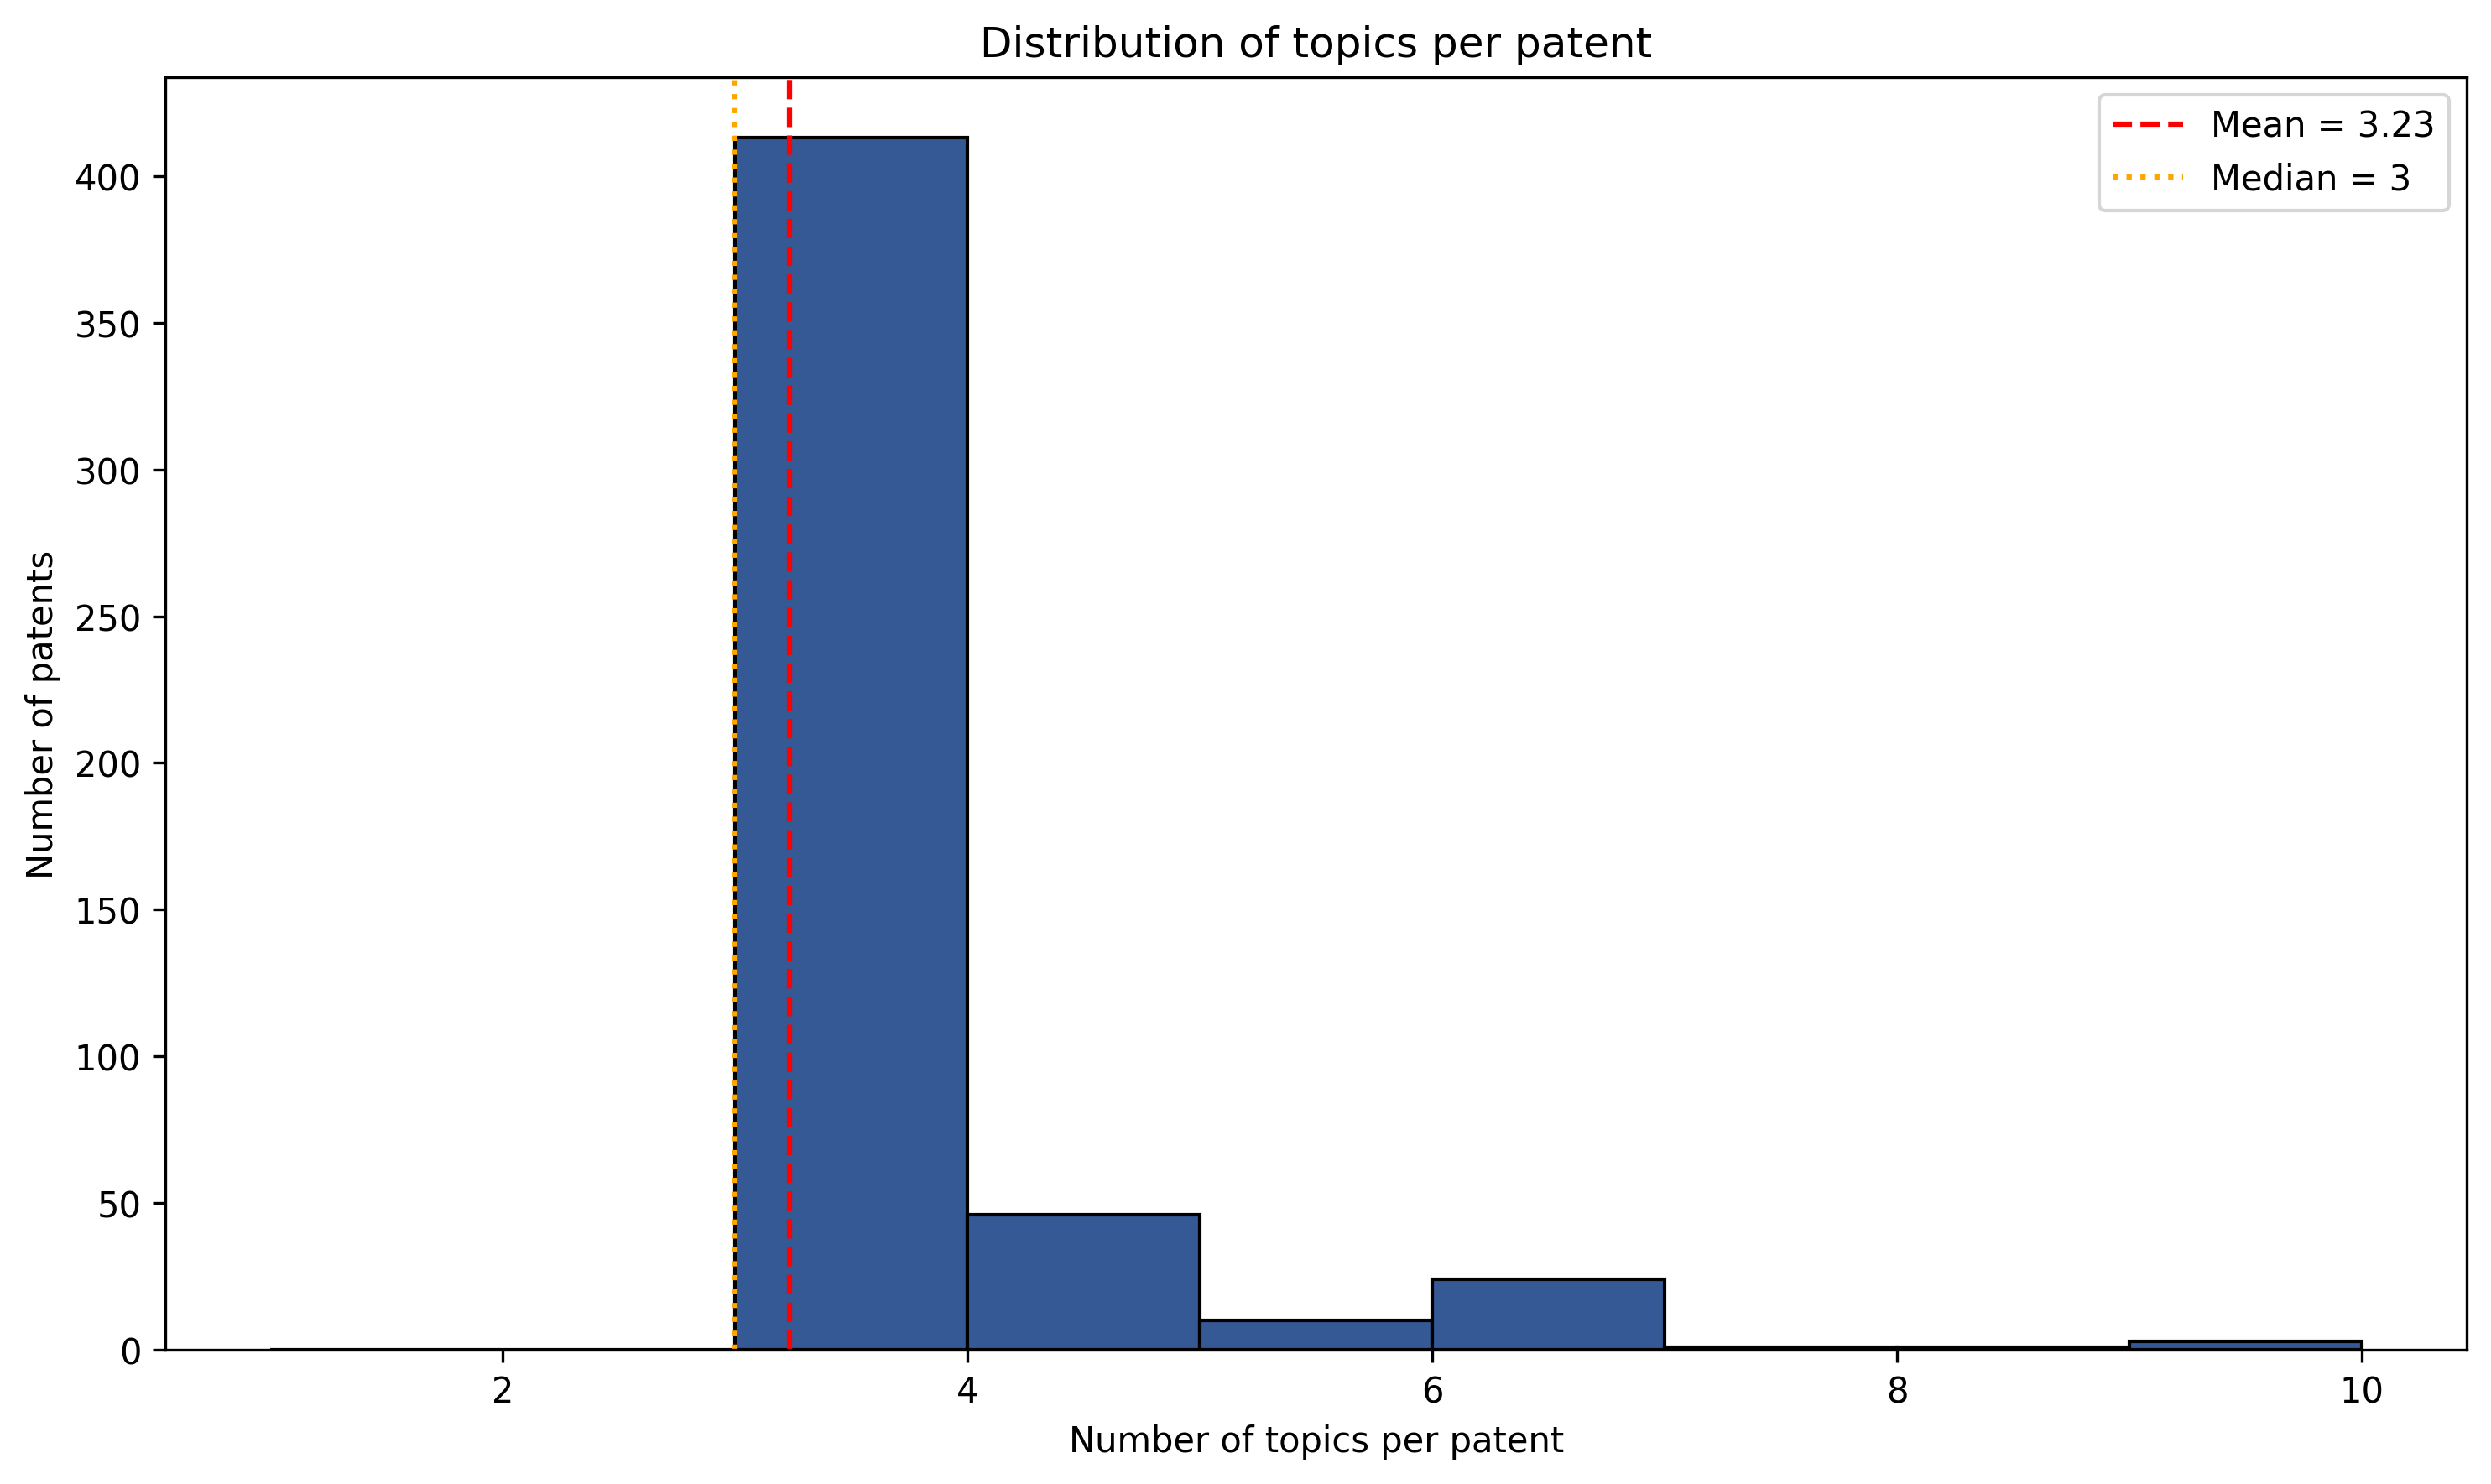

In [6]:
# Visualize topic distribution
patent.plot_topics_histogram(
    df_with_iso,
    n_topics_col='n_topics',
    colors=colors_scheme[3],
    figsize=(10, 6),
    savefile=None
)

✓ Found 69 unique topics


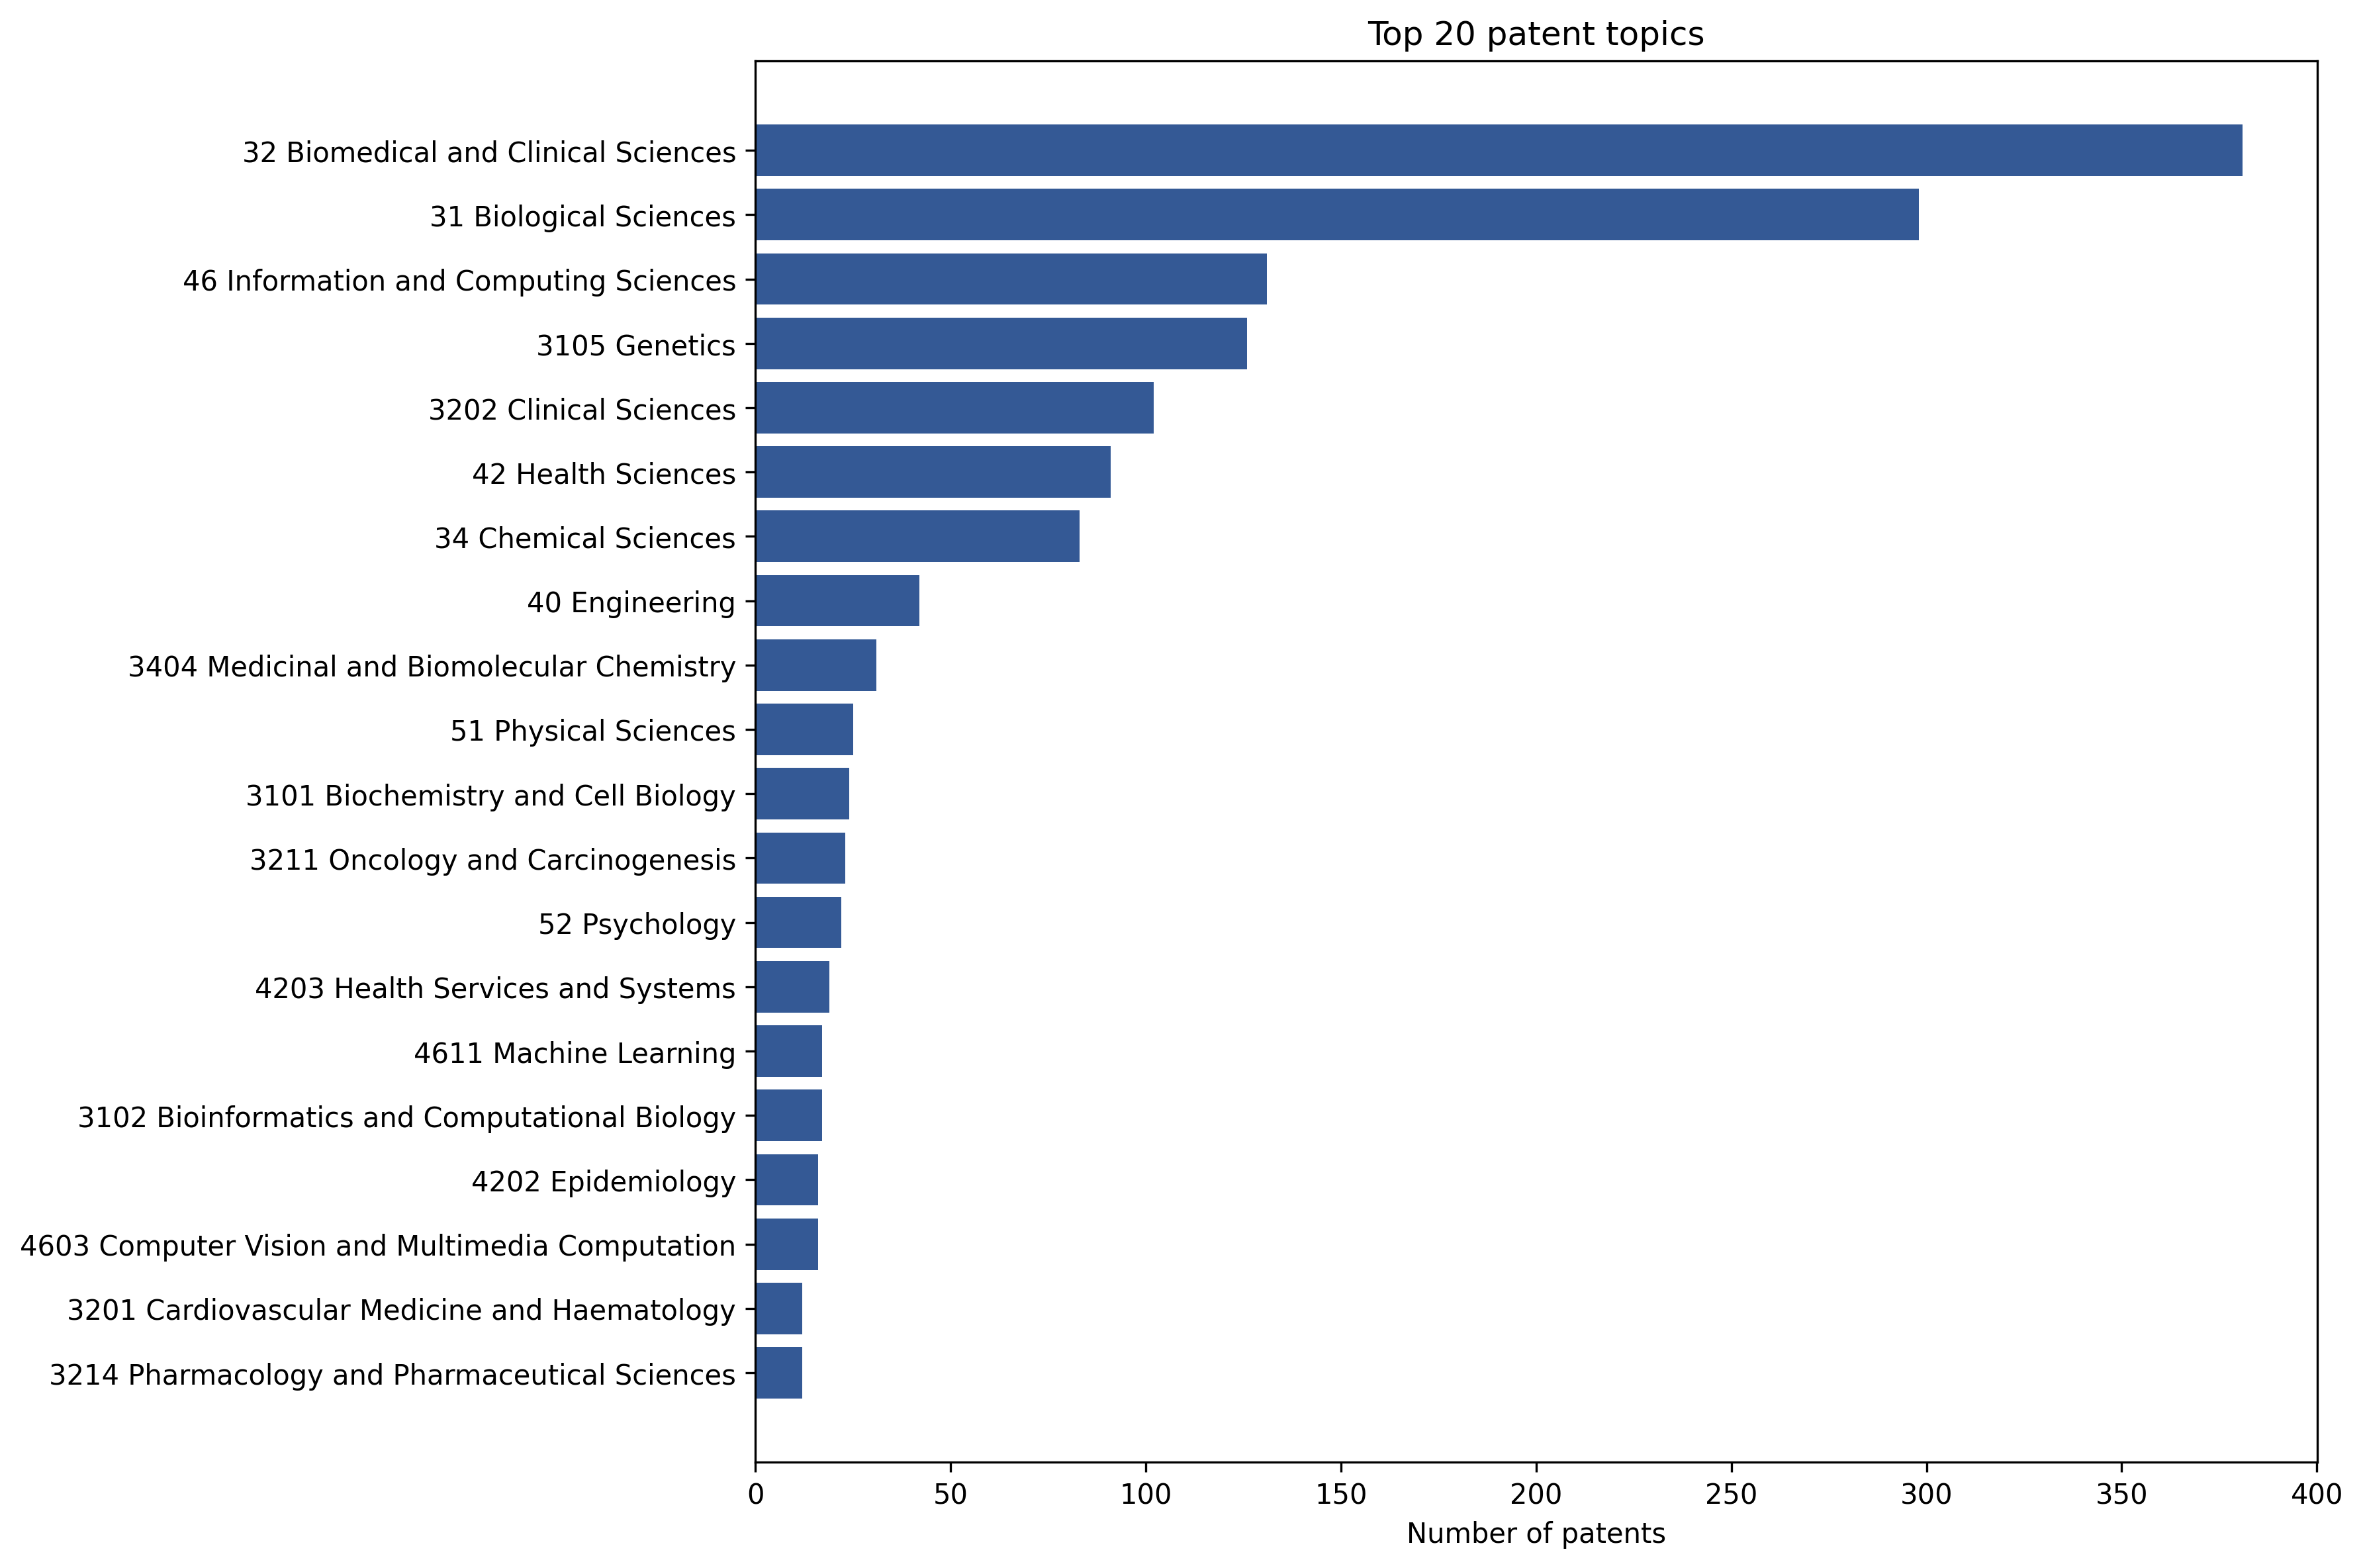

In [7]:
# Build top-level topic counts (fractional counting)
topic_counter = Counter()
for topics in df_with_iso['topics_list']:
    for t in topics:
        topic_counter[t] += 1

topic_df = (
    pd.DataFrame(topic_counter.items(), columns=['topic', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f"✓ Found {len(topic_df)} unique topics")

# Visualize top topics
patent.plot_top_topics_horizontal(
    topic_df,
    topic_col='topic',
    count_col='count',
    top_n=20,
    colors=[colors_scheme[3]],
    figsize=(12, 8),
    savefile=None #'fig/patent/top_topics.png'
)

## 5. Load Pre-computed LLM Classification Results

Load pre-computed LLM tags for proteomics and drug development instead of re-running the models.

In [8]:
# Load pre-computed drug development classification results
df_drug_dev_results = pd.read_csv("data/patent/patent_drug_dev_checkpoint.csv")

# Load pre-computed proteomics classification results
df_proteomics_results = pd.read_csv("data/patent/patent_proteomics_checkpoint.csv")

print(f"✓ Loaded drug development classification: {len(df_drug_dev_results)} patents")
print(f"✓ Loaded proteomics classification: {len(df_proteomics_results)} patents")

# Check available columns
print(f"\nDrug development columns: {df_drug_dev_results.columns.tolist()}")
print(f"Proteomics columns: {df_proteomics_results.columns.tolist()}")


✓ Loaded drug development classification: 513 patents
✓ Loaded proteomics classification: 504 patents

Drug development columns: ['Unnamed: 0', 'abstract', 'additional_filters', 'application_number', 'assignee_cities', 'assignee_countries', 'assignee_names', 'assignees', 'category_for', 'category_for_2020', 'category_rcdc', 'claims_amount', 'cpc', 'current_assignee_names', 'current_assignees', 'date', 'date_inserted', 'dimensions_url', 'expiration_date', 'family_count', 'family_id', 'filing_date', 'filing_status', 'id', 'inventor_names', 'inventors', 'ipcr', 'jurisdiction', 'kind', 'legal_status', 'original_assignee_names', 'original_assignees', 'priority_date', 'priority_year', 'publication_date', 'publication_ids', 'publication_year', 'publications', 'score', 'times_cited', 'title', 'year', 'reference_ids', 'category_bra', 'category_hra', 'category_hrcs_rac', 'category_icrp_cso', 'category_icrp_ct', 'category_hrcs_hc', 'granted_date', 'granted_year', 'assignee_state_codes', 'associat

In [9]:
# Merge drug development results with main dataset
df_with_iso = df_with_iso.merge(
    df_drug_dev_results[['id', 'drug_dev_label', 'development_stage', 'drug_dev_confidence', 'drug_dev_rationale']],
    on='id',
    how='left'
)

# Merge proteomics results with main dataset
df_with_iso = df_with_iso.merge(
    df_proteomics_results[['id', 'label', 'confidence', 'rationale']],
    on='id',
    how='left',
    suffixes=('', '_proteomics')
)

# Rename proteomics columns for clarity
if 'label' in df_with_iso.columns:
    df_with_iso.rename(columns={'label': 'proteomics_label'}, inplace=True)
if 'confidence' in df_with_iso.columns:
    df_with_iso.rename(columns={'confidence': 'proteomics_confidence'}, inplace=True)
if 'rationale' in df_with_iso.columns:
    df_with_iso.rename(columns={'rationale': 'proteomics_rationale'}, inplace=True)

print(f"✓ Merged classifications with main dataset")
print(f"\nClassification summary:")
print(f"  Drug development 'yes': {(df_with_iso['drug_dev_label'] == 'yes').sum()}")
print(f"  Drug development 'no': {(df_with_iso['drug_dev_label'] == 'no').sum()}")
print(f"  Proteomics 'yes': {(df_with_iso['proteomics_label'] == 'yes').sum()}")
print(f"  Proteomics 'no': {(df_with_iso['proteomics_label'] == 'no').sum()}")


✓ Merged classifications with main dataset

Classification summary:
  Drug development 'yes': 230
  Drug development 'no': 267
  Proteomics 'yes': 8
  Proteomics 'no': 480


## 6. Visualize Filing Status and Patents Over Time

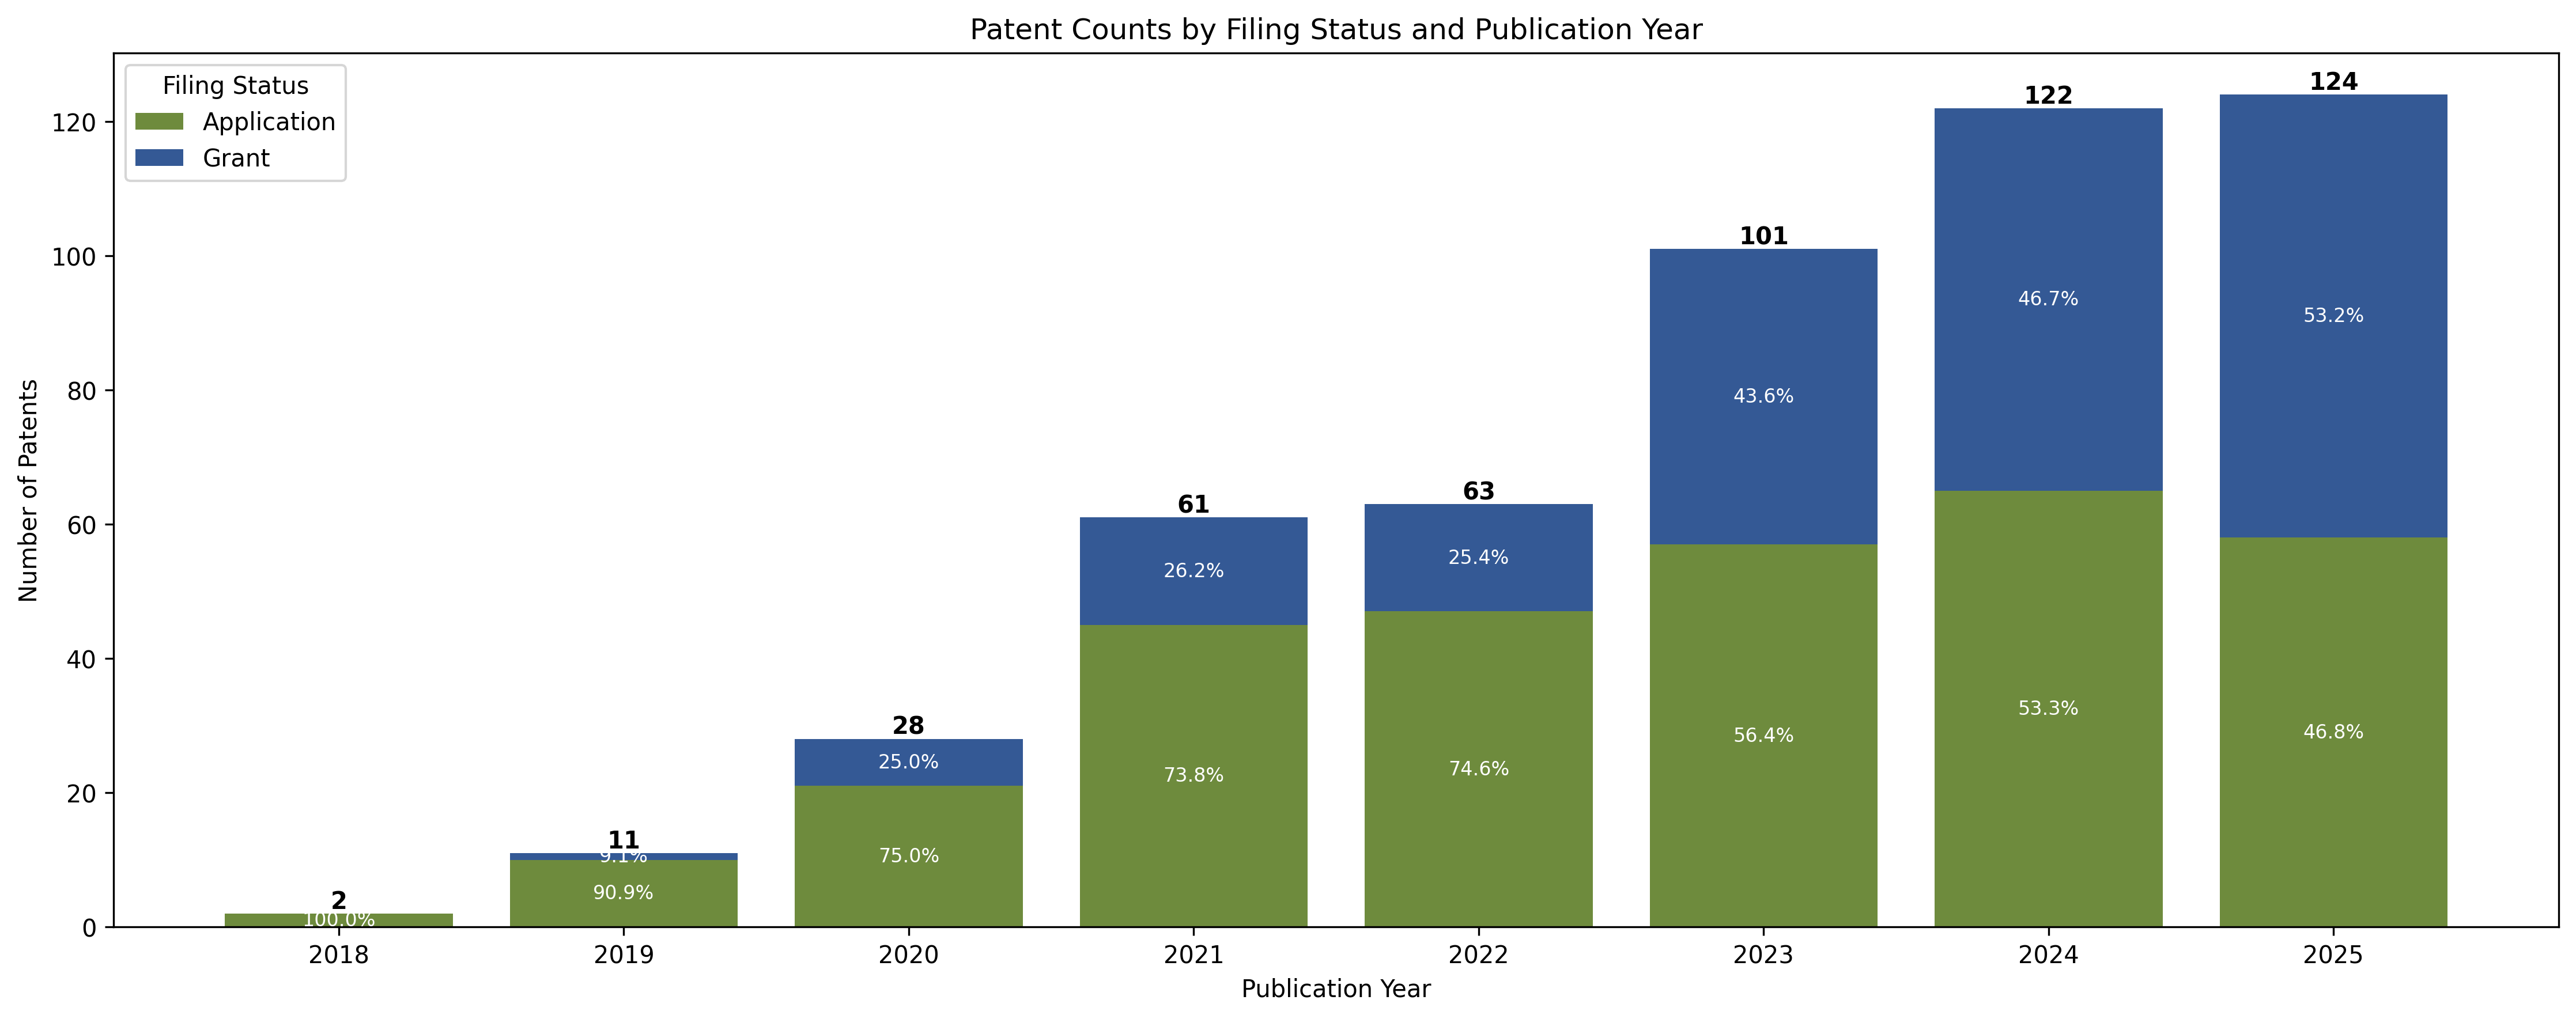

In [10]:
# Plot patent counts by filing status
patent.plot_patent_counts_by_filing_status(
    df_with_iso,
    date_col='publication_date',
    year_col='publication_year',
    filing_status_col='filing_status',
    colors=colors_scheme[2:5],
    figsize=(15, 6),
    savefile=None #'fig/patent/filing_status_timeline.png'
)

## 7. Drug Development Patent Analysis

✓ Drug development patents identified: 230

Development stage distribution:
development_stage
clinical/therapeutic use       139
target discovery                66
preclinical                     22
preclinical/therapeutic use      3
Name: count, dtype: int64

Drug development confidence levels:
drug_dev_confidence
high    230
Name: count, dtype: int64


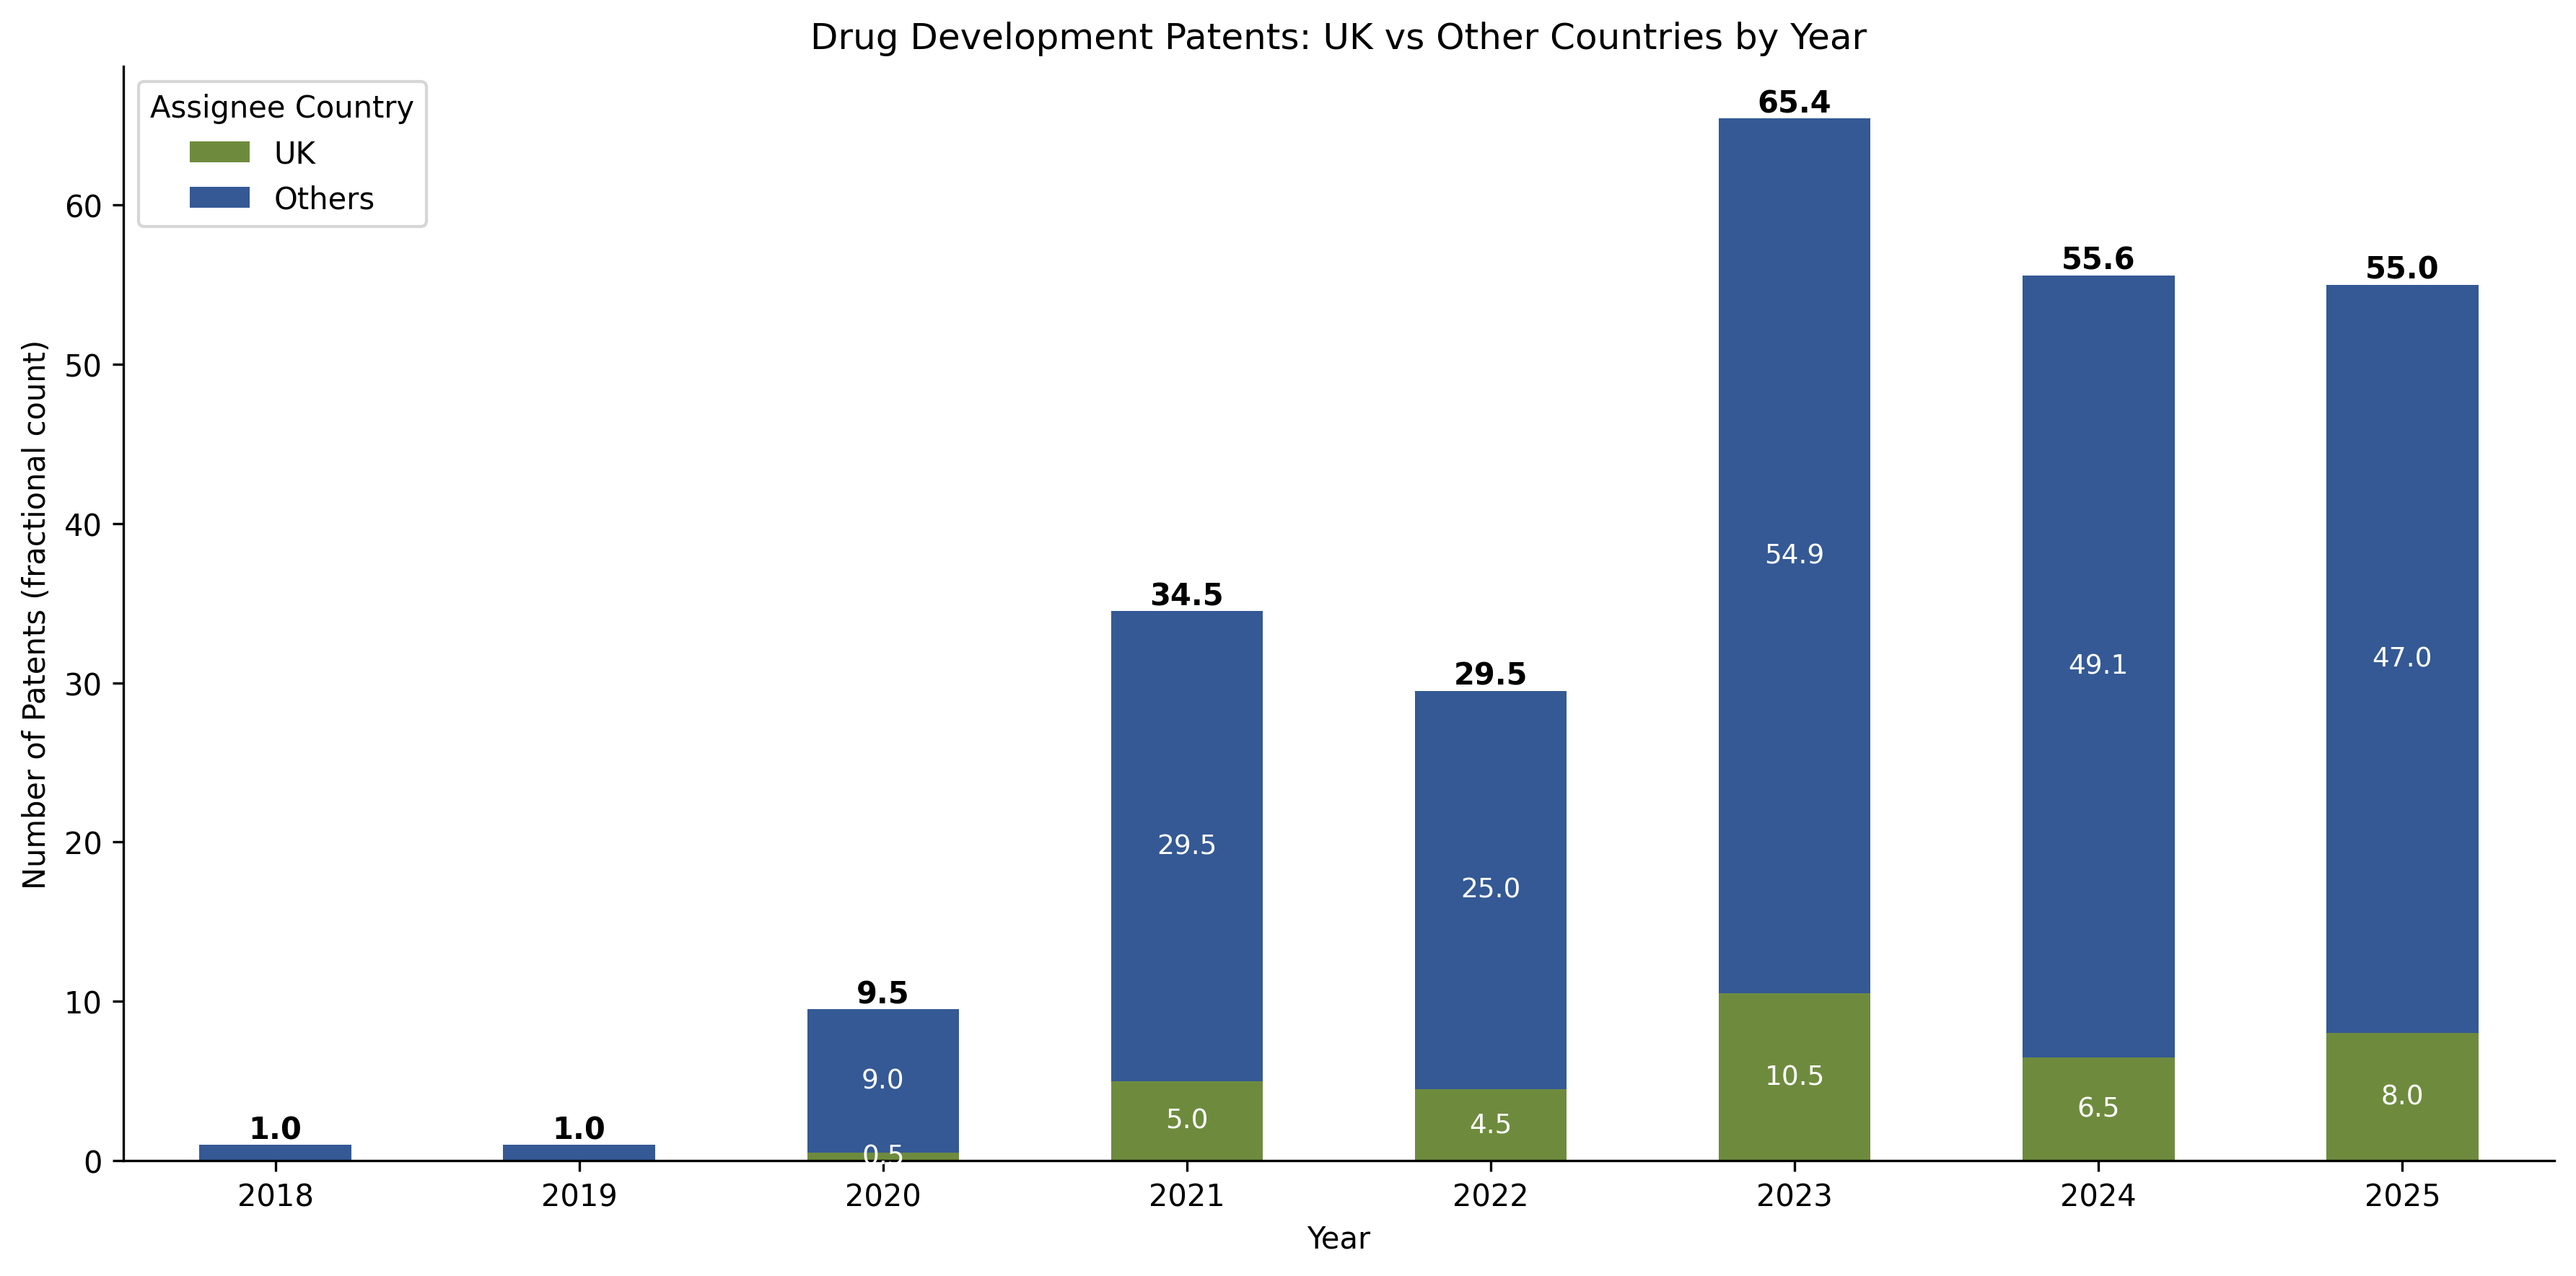

In [11]:
# Filter drug development patents
df_drug_dev = df_with_iso[df_with_iso['drug_dev_label'] == 'yes'].copy()
df_drug_dev_exploded = df_drug_dev.explode('assignee_countries')
df_drug_dev_exploded['weight'] = 1.0 / df_drug_dev_exploded.groupby('application_number')['application_number'].transform('count')

print(f"✓ Drug development patents identified: {len(df_drug_dev)}")
print(f"\nDevelopment stage distribution:")
print(df_drug_dev['development_stage'].value_counts())
print(f"\nDrug development confidence levels:")
print(df_drug_dev['drug_dev_confidence'].value_counts())

# Plot UK vs Others
patent.plot_drug_dev_by_country(
    df_drug_dev_exploded,
    country_col='assignee_countries',
    year_col='year',
    weight_col='weight',
    uk_code='GB',
    colors=[colors_scheme[2], colors_scheme[3]],
    figsize=(12, 6),
    savefile= None #'fig/patent/drug_dev_uk_vs_others.png'
)

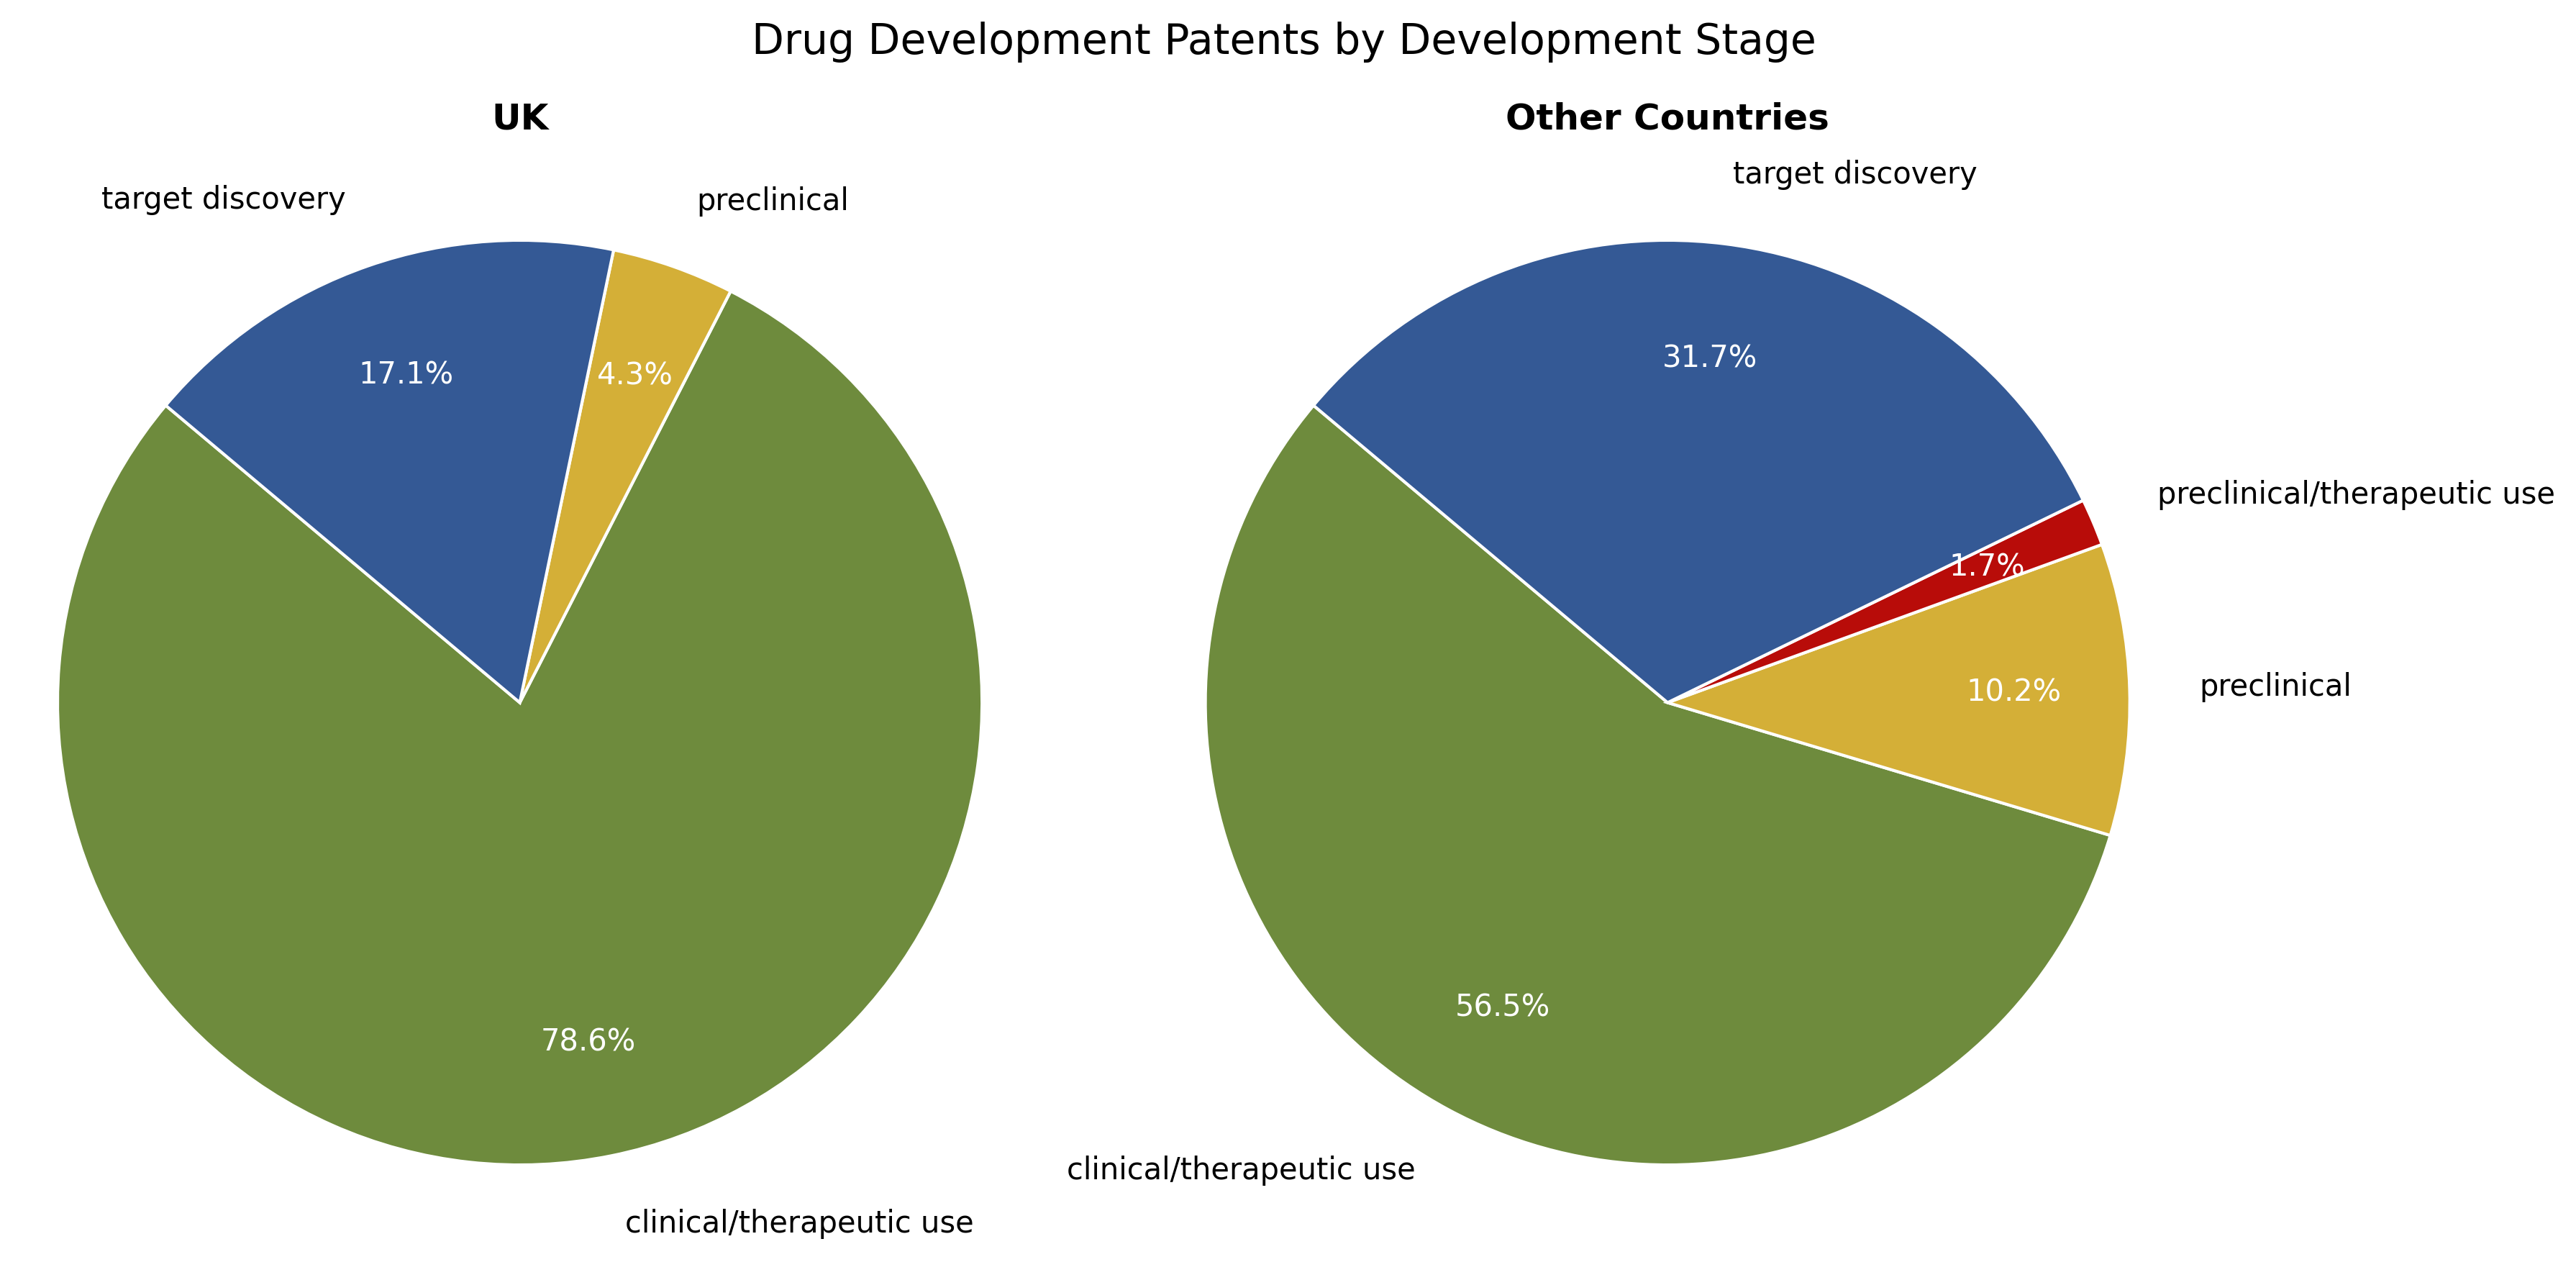

In [12]:
# Analyze development stage by country
df_stage = (
    df_drug_dev_exploded
    .groupby(['assignee_countries','development_stage'])
    .agg({'weight': 'sum'})
    .reset_index()
)

# Plot development stage comparison
patent.plot_development_stage_pies(
    df_stage,
    country_col='assignee_countries',
    stage_col='development_stage',
    weight_col='weight',
    uk_code='GB',
    colors=colors_scheme,
    figsize=(12, 6),
    savefile=None#'fig/patent/dev_stage_uk_vs_others.png'
)

## 8. UKBB Paper Citation Analysis

✓ Found 336 UKBB papers cited in patents
✓ Total citations: 705


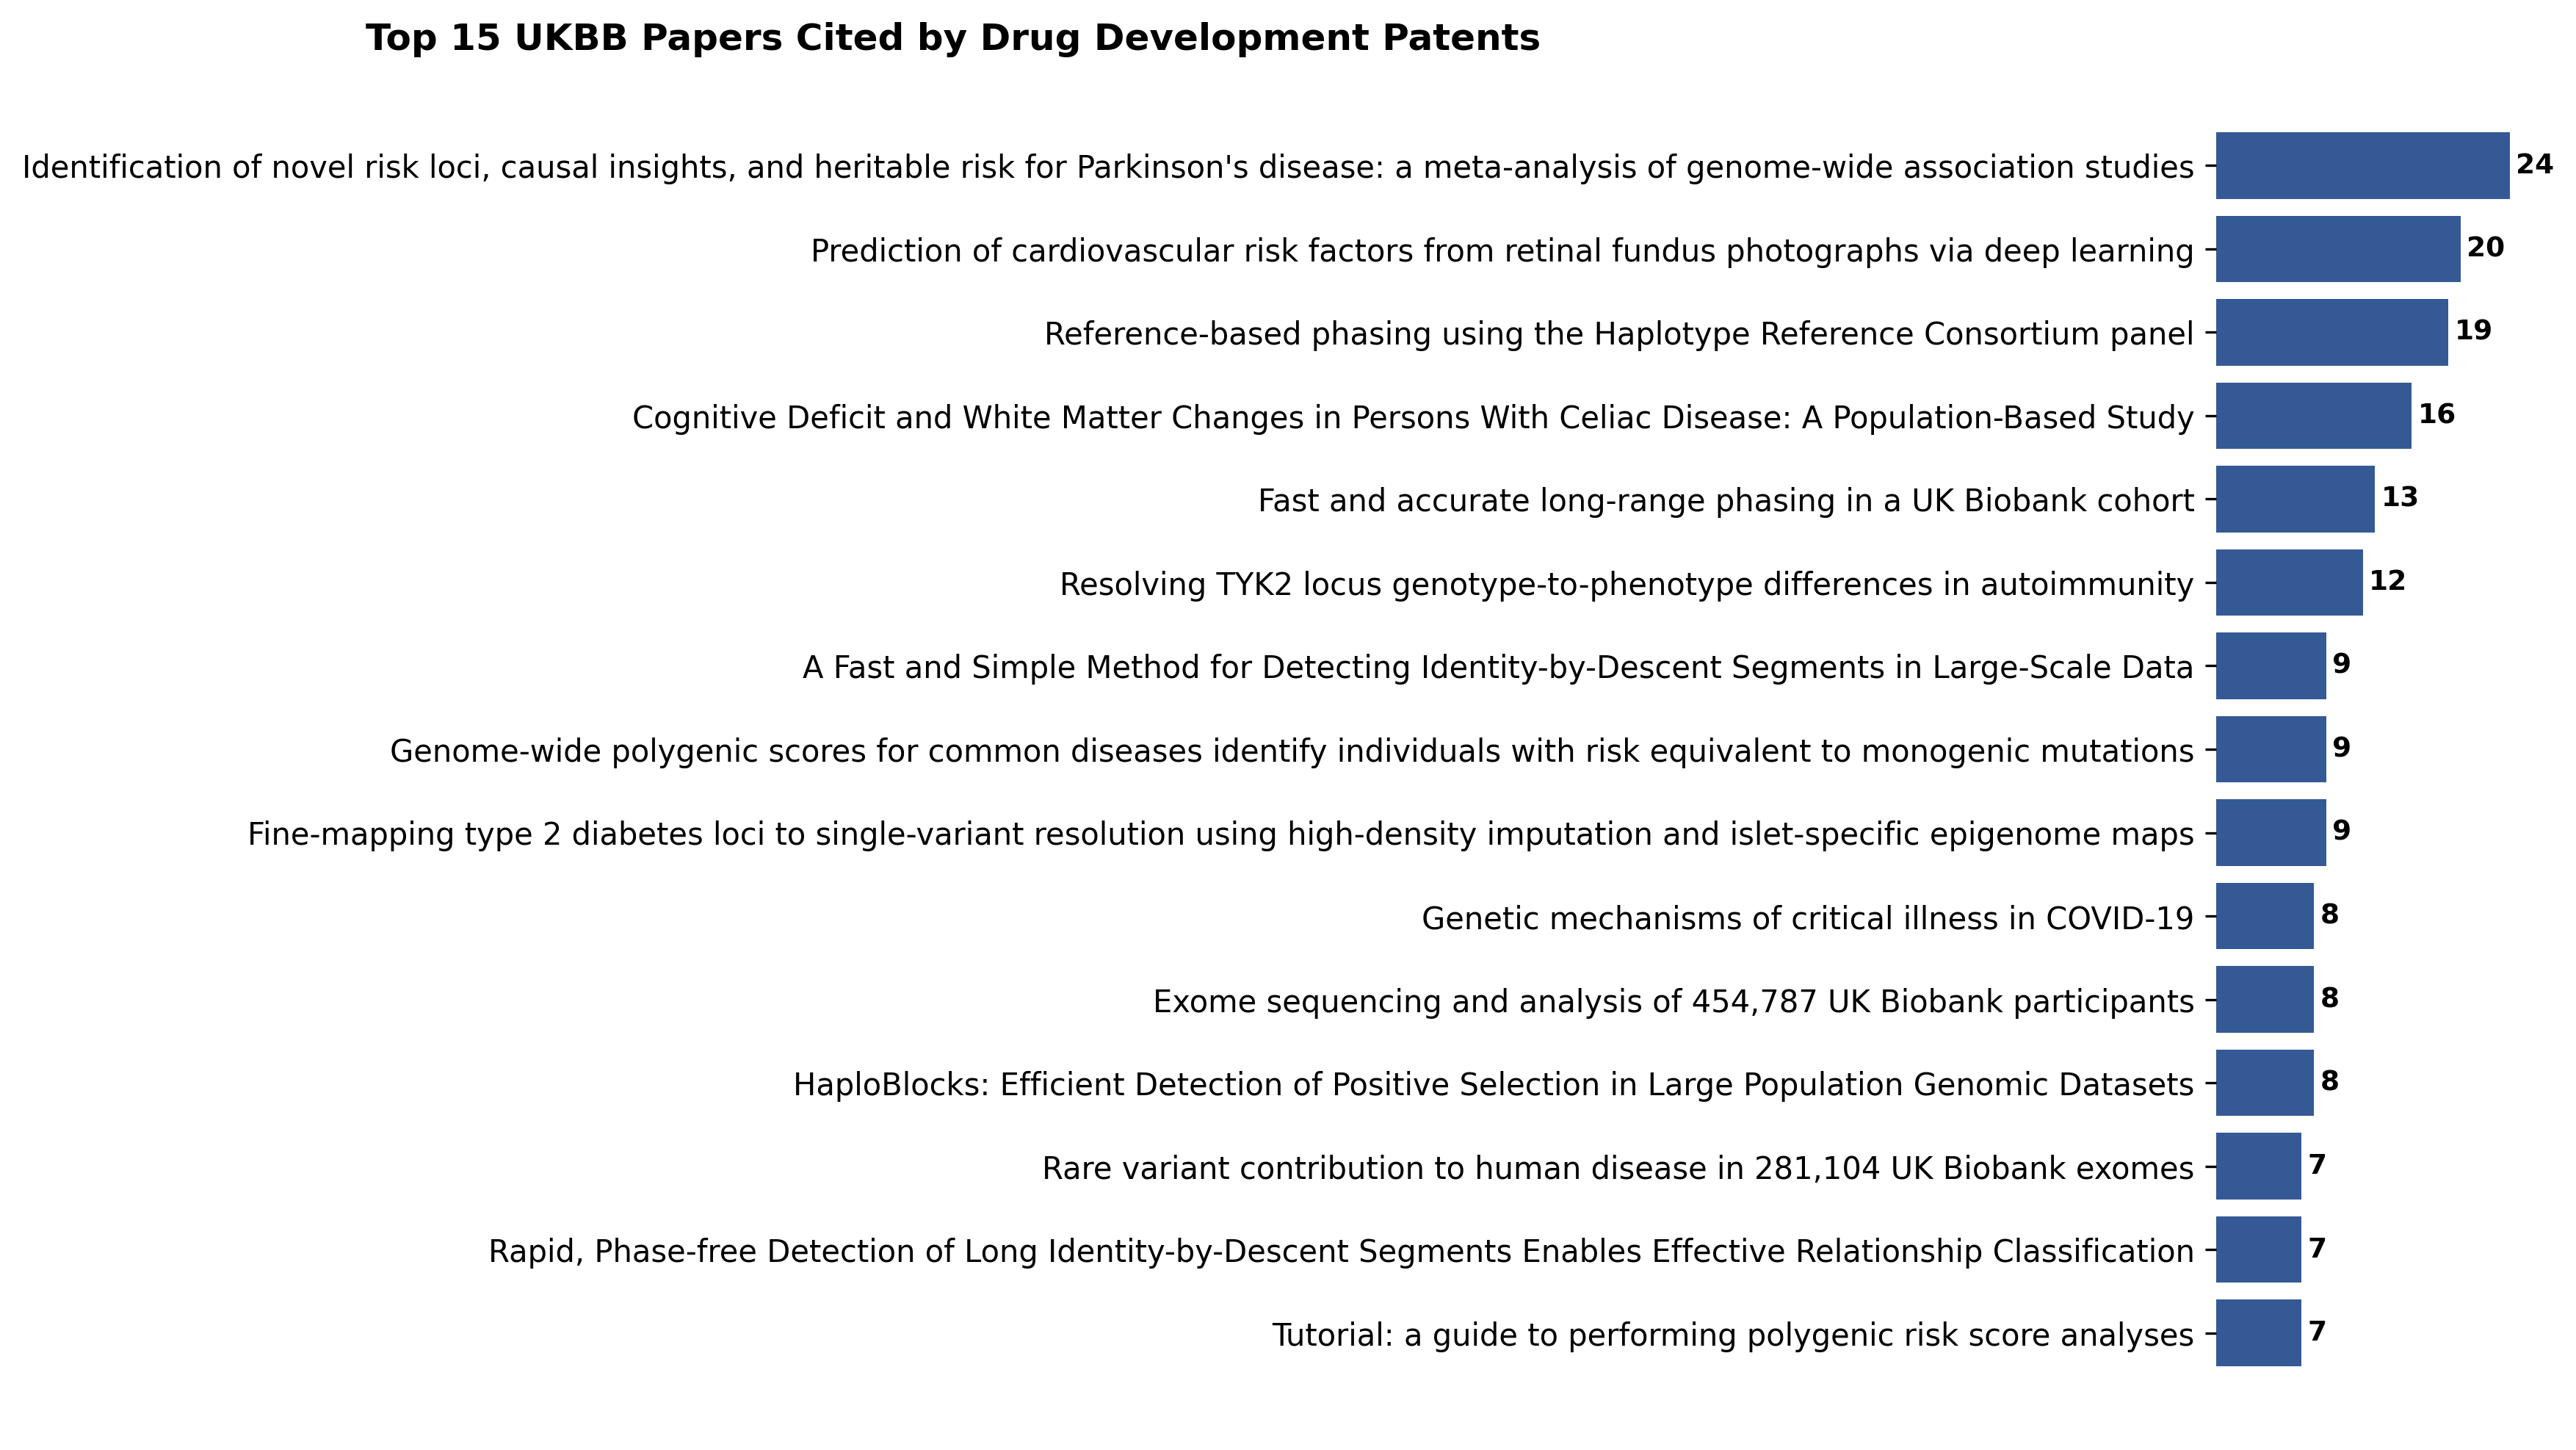

In [13]:
# Find UKBB papers cited in patents
df_with_iso['in_ukbb'] = df_with_iso['publication_ids'].apply(
    lambda x: patent.find_ukbb_papers(x, df_all_ukbb['id'].tolist())
)

# Count paper citations
paper_counter = Counter()
for papers in df_with_iso['in_ukbb']:
    for p in papers:
        paper_counter[p] += 1

df_drug_dev_cited_papers = pd.DataFrame(paper_counter.items(), columns=['id', 'count']).sort_values('count', ascending=False)
df_drug_dev_cited_papers = df_drug_dev_cited_papers.merge(df_all_ukbb, on='id', how='left')

print(f"✓ Found {len(df_drug_dev_cited_papers)} UKBB papers cited in patents")
print(f"✓ Total citations: {df_drug_dev_cited_papers['count'].sum()}")

# Plot top cited papers
patent.plot_top_cited_papers(
    df_drug_dev_cited_papers,
    title_col='title',
    count_col='count',
    top_n=15,
    colors=[colors_scheme[3]],
    figsize=(14, 8),
    savefile=None#'fig/patent/top_cited_papers.png'
)


## 9. Proteomics Patent Analysis

In [ ]:
# Analyze proteomics patents
df_proteomics = df_with_iso[df_with_iso['proteomics_label'] == 'yes'].copy()

print(f"✓ Proteomics patents identified: {len(df_proteomics)}")
print(f"\nProteomics confidence levels:")
print(df_with_iso['proteomics_confidence'].value_counts(dropna=False))

# Summary statistics
print(f"\nPatent Classification Summary:")
print(f"  Total patents: {len(df_with_iso)}")
print(f"  Drug development related: {(df_with_iso['drug_dev_label'] == 'yes').sum()} ({(df_with_iso['drug_dev_label'] == 'yes').sum()/len(df_with_iso)*100:.1f}%)")
print(f"  Proteomics related: {(df_with_iso['proteomics_label'] == 'yes').sum()} ({(df_with_iso['proteomics_label'] == 'yes').sum()/len(df_with_iso)*100:.1f}%)")
print(f"  Both drug dev AND proteomics: {((df_with_iso['drug_dev_label'] == 'yes') & (df_with_iso['proteomics_label'] == 'yes')).sum()}")
